In [8]:
# ===== 기본 세트 (거의 항상 필요) =====
import pandas as pd                    # 데이터프레임 다루기 (표 형태 데이터 처리)
import numpy as np                     # 수치 계산, 배열 연산
import matplotlib.pyplot as plt        # 기본 시각화
import seaborn as sns                  # matplotlib 기반의, 더 예쁘고 간결한 통계 시각화

# ===== 파일/경로/시스템 =====
import os                              # 파일 경로 확인, 파일 존재 여부(os.path.exists) 등
from pathlib import Path               # 폴더/파일 경로를 객체로 다루기 (work_dir / "파일명")
import joblib                          # 학습된 scaler/encoder를 파일로 저장하고 재사용
import platform                        # OS 종류 확인 (Windows/Mac/Linux 구분 필요할 때)
import warnings                        # 경고 메시지 제어(숨기기/표시)

# ===== 벤치마크/성능 측정 =====
import time                            # 코드 실행 시간 측정 (time.perf_counter())
import psutil                          # 메모리 사용량 측정 (rss_mb 등)
import gc                              # 메모리 강제 정리(garbage collection)

# ===== 결측치 탐색 시각화 =====
import missingno as msno               # 결측치 위치(matrix), 관계(heatmap) 시각화

# ===== 인터랙티브 시각화 =====
import plotly.express as px            # 마우스 hover/zoom 가능한 인터랙티브 그래프
import plotly.io as pio                 # plotly 렌더러(출력 방식) 설정

# ===== 대용량 데이터 처리 =====
import polars as pl                     # pandas보다 빠른 대용량 데이터 처리 (Rust 기반)

# ===== 통계 검증 =====
import statsmodels.api as sm            # 회귀분석, 다중공선성(Cond. No.) 등 통계 검증
from scipy import stats
from statsmodels.stats.power import TTestIndPower

# ===== 한글 폰트 설정 =====
import matplotlib.font_manager as fm    # 그래프에 한글 폰트 적용 시 필요
import matplotlib.pyplot as plt

font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

# ===== 인코딩/스케일링/모델링 (sklearn) =====
from sklearn.preprocessing import LabelEncoder      # 카테고리를 숫자로 변환 (순서형)
from sklearn.preprocessing import MinMaxScaler       # 0~1 범위로 스케일링
from sklearn.preprocessing import StandardScaler     # 평균0, 표준편차1로 스케일링
from sklearn.preprocessing import RobustScaler       # 이상치에 강한 스케일링 (median/IQR 기반)
from sklearn.linear_model import LinearRegression    # 선형 회귀 모델
from sklearn.linear_model import LogisticRegression  # 로지스틱 회귀(분류) 모델
from sklearn.ensemble import RandomForestRegressor   # 랜덤포레스트(트리 기반) 모델
from sklearn.metrics import roc_auc_score, log_loss  # 분류 모델 평가지표

In [2]:
# 문제 1 · 데이터 준비 — 실행만 하세요
penguins = sns.load_dataset('penguins')
mass = penguins.dropna(subset=['body_mass_g', 'species'])

adelie    = mass.loc[mass['species'] == 'Adelie',    'body_mass_g']
chinstrap = mass.loc[mass['species'] == 'Chinstrap', 'body_mass_g']

print("Adelie    n=%3d   평균 %.1f g   표준편차 %.1f g" % (len(adelie),    adelie.mean(),    adelie.std(ddof=1)))
print("Chinstrap n=%3d   평균 %.1f g   표준편차 %.1f g" % (len(chinstrap), chinstrap.mean(), chinstrap.std(ddof=1)))

diff_g = adelie.mean() - chinstrap.mean()
print("\n두 종의 평균 차이: %.1f g  (Adelie 몸무게의 약 %.1f%%)" % (diff_g, abs(diff_g) / adelie.mean() * 100))

Adelie    n=151   평균 3700.7 g   표준편차 458.6 g
Chinstrap n= 68   평균 3733.1 g   표준편차 384.3 g

두 종의 평균 차이: -32.4 g  (Adelie 몸무게의 약 0.9%)


In [3]:
#Q1 · 두 종의 몸무게를 t-검정으로 비교해 봅시다

# 1. 정규성 검정
for name, data in [("Adelie", adelie), ("Chinstrap", chinstrap)]:
    stat, p = stats.shapiro(data)
    print(f"{name} 정규성 p-값: {p:.4f}")

# 2. 등분산성 검정 (Levene)
levene_stat, levene_p = stats.levene(adelie, chinstrap)
print(f"\nLevene 등분산성 p-값: {levene_p:.4f}")

# 3. t-검정 (등분산 여부에 따라 equal_var 결정)
equal_var = levene_p >= 0.05
t_stat, p_value = stats.ttest_ind(adelie, chinstrap, equal_var=equal_var)

print(f"\n{'등분산 가정' if equal_var else 'Welch (분산 다름 가정)'} t-검정")
print(f"t-통계량: {t_stat:.4f}")
print(f"p-값: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"→ p-value < {alpha}: 귀무가설을 기각한다. 두 종의 평균 몸무게는 통계적으로 유의하게 다르다.")
else:
    print(f"→ p-value >= {alpha}: 귀무가설을 기각하지 못한다.")

Adelie 정규성 p-값: 0.0324
Chinstrap 정규성 p-값: 0.5605

Levene 등분산성 p-값: 0.0291

Welch (분산 다름 가정) t-검정
t-통계량: -0.5431
p-값: 0.587861
→ p-value >= 0.05: 귀무가설을 기각하지 못한다.


In [4]:
# Q2 · 효과크기(Cohen's d)를 직접 계산해 봅시다
def cohen_d(x, y):
    n_x = len(x)
    n_y = len(y)
    
    pooled_std = np.sqrt(
        ((n_x - 1) * x.std(ddof=1)**2 + (n_y - 1) * y.std(ddof=1)**2) / (n_x + n_y - 2)
    )
    
    d = (x.mean() - y.mean()) / pooled_std
    return d

d_value = cohen_d(adelie, chinstrap)

print(f"Cohen's d: {d_value:.4f}")

abs_d = abs(d_value)
if abs_d < 0.2:
    size = "매우 작음(무시할 만함)"
elif abs_d < 0.5:
    size = "작음"
elif abs_d < 0.8:
    size = "중간"
else:
    size = "큼"

print(f"효과크기 판정: {size}")


Cohen's d: -0.0742
효과크기 판정: 매우 작음(무시할 만함)


In [5]:
# Q3 · 표본을 늘려 가며 p-값과 효과크기를 함께 추적해 봅시다
# 모집단 참값으로 고정
mean_a = adelie.mean()
mean_c = chinstrap.mean()
pooled_std = np.sqrt(
    ((len(adelie)-1)*adelie.std(ddof=1)**2 + (len(chinstrap)-1)*chinstrap.std(ddof=1)**2) 
    / (len(adelie)+len(chinstrap)-2)
)

print(f"모집단 참값: Adelie 평균={mean_a:.1f}g, Chinstrap 평균={mean_c:.1f}g, 통합표준편차={pooled_std:.1f}g")
print(f"실제 차이: {mean_a - mean_c:.1f}g\n")

np.random.seed(42)
n_list = [30, 150, 1000, 5000, 20000]
n_repeats = 400

results = []

for n in n_list:
    p_values = []
    d_values = []
    
    for i in range(n_repeats):
        sample_a = np.random.normal(mean_a, pooled_std, n)
        sample_c = np.random.normal(mean_c, pooled_std, n)
        
        t_stat, p_val = stats.ttest_ind(sample_a, sample_c)
        d_val = cohen_d(pd.Series(sample_a), pd.Series(sample_c))
        
        p_values.append(p_val)
        d_values.append(d_val)
    
    results.append({
        "n": n,
        "p-값 중위수": np.median(p_values),
        "p<0.05 비율(%)": (np.array(p_values) < 0.05).mean() * 100,
        "Cohen's d 평균": np.mean(d_values)
    })

result_df = pd.DataFrame(results)
print(result_df.to_string(index=False))


모집단 참값: Adelie 평균=3700.7g, Chinstrap 평균=3733.1g, 통합표준편차=437.0g
실제 차이: -32.4g

    n      p-값 중위수  p<0.05 비율(%)  Cohen's d 평균
   30 4.832362e-01          4.25     -0.052228
  150 4.072083e-01          8.75     -0.071458
 1000 8.515674e-02         39.00     -0.074708
 5000 2.514052e-04         97.50     -0.074059
20000 1.391721e-13        100.00     -0.074061


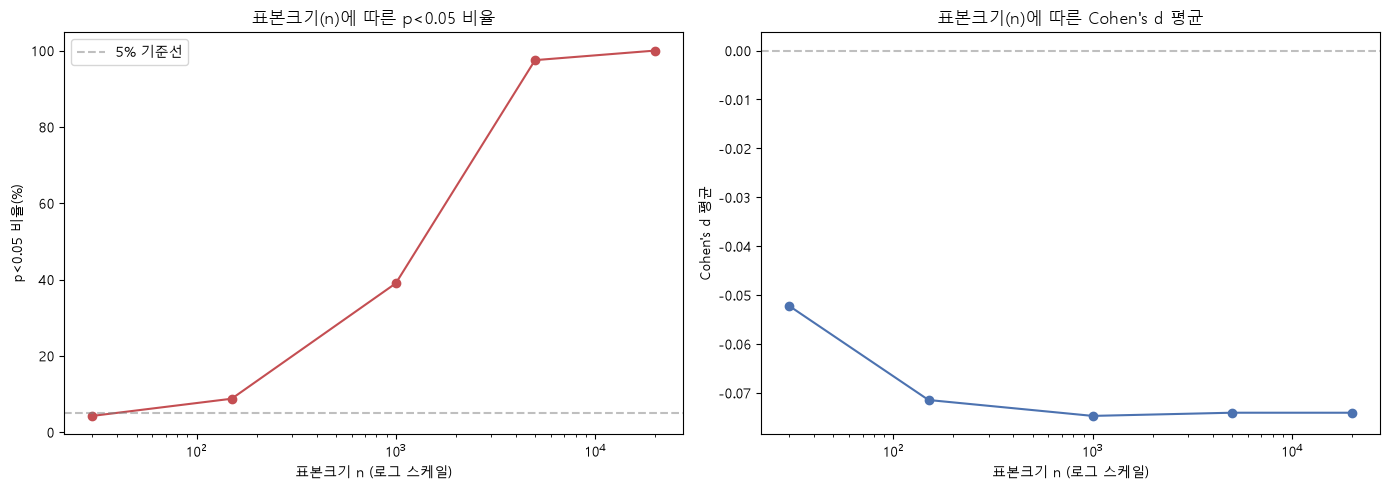

In [6]:
# Q4 · 결과를 그래프로 그려 봅시다
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: n에 따른 p<0.05 비율
axes[0].plot(result_df["n"], result_df["p<0.05 비율(%)"], marker="o", color="#C44E52")
axes[0].set_xscale("log")
axes[0].set_title("표본크기(n)에 따른 p<0.05 비율")
axes[0].set_xlabel("표본크기 n (로그 스케일)")
axes[0].set_ylabel("p<0.05 비율(%)")
axes[0].axhline(5, color="gray", linestyle="--", alpha=0.5, label="5% 기준선")
axes[0].legend()

# 오른쪽: n에 따른 Cohen's d 평균
axes[1].plot(result_df["n"], result_df["Cohen's d 평균"], marker="o", color="#4C72B0")
axes[1].set_xscale("log")
axes[1].set_title("표본크기(n)에 따른 Cohen's d 평균")
axes[1].set_xlabel("표본크기 n (로그 스케일)")
axes[1].set_ylabel("Cohen's d 평균")
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


💬 정리 · 결과를 말로 설명해 보기
Q1에서 두 종의 몸무게는 통계적으로 유의한 차이가 없었습니다. 그런데 Q3에서 n=5,000일 때는 95% 이상 유의하게 나왔습니다. 같은 32g인데 결론이 갈린 이유는 무엇인가요?
▸ 유의수준은 0.05로 동일하지만 표본의 수가 증가할수록 p-value 즉 발생할 확률이 점차 감소하기 때문에 n=5000일 때 극단적으로 95%가 유의한 것으로 결과가 나온다.

Q3의 표에서 n이 커질 때 p-값은 어떻게 변했나요? Cohen's d는 어떻게 변했나요? 이 대비가 뜻하는 바를 한 문장으로 정리해 보세요.
▸ n 30에서 20000으로 커질수록 p-값은 점차 작아졌지만(0.483 -> 1.39×10⁻¹³) Cohen's d 평균는 n수가 30 또는 20000이어도 영향이 거의 없는 것으로 확인되었다.(-0.052, -0.074)
표본이 커질수록 표본의 평균과 모집단의 평균간의 차이는 없지만 표본 커질수록 p-값은 점차 감소하여 유의미한 수준에 다르게 된다.
(평균 차이를 표준편차 단위로 나누어 측정하는 대표적인 효과 크기(effect size) 지표)

"통계적으로 유의하다"와 "실질적으로 의미 있다"는 같은 말인가요? 펭귄 32g을 예로 설명해 보세요.
▸ 표본 20000인 경우 단순 통계적 계산 결과로는 32g의 몸무게 차이는 p-value 0.05 미만으로 유의미한 결과를 보이지만 효과 크기(Cohen's d: -0.0742) 상관이 매우 적다고 확인하였다.

A/B 테스트에서 버튼 색을 바꿨더니 클릭률이 0.1%p 올랐고 p-값은 0.001이었습니다. 이 결과만으로 버튼을 바꿔야 한다고 말할 수 있을까요?
▸ p-값이 0.001로 유의미한 결과를 보여주더라도 실제 클릭률은 전체 대비 0.1%만 올랐기 때문에 효과크기(Cohen's d)를 함께 확인하여 버튼을 바꿔야할지 말지 의사 결정에 보충을 해야한다.

논문이나 보고서에 p-값만 적는 것이 왜 부족한가요? 무엇을 함께 적어야 할까요?
▸ p-값만 적는 경우 위의 펭귄의 몸무게 또는 A/B 테스트처럼 단순 검정에 대한 유의수준만 설명하고 실제 상관관계를 설명하지는 못하기 때문에 효과크기(Cohen's d)를 같이 설명하여 펭귄 몸무게가 실질적인 상관이 있거나 클릭률의 변경이 버튼 색과 상관이 어느 정도 강도로 보여지는지 보충하여야 한다.

In [9]:
# 문제 2 · 데이터 준비 — 실행만 하세요
# 문제 1의 Q2·Q3를 먼저 완료해야 이 문제를 풀 수 있습니다.

analysis = TTestIndPower()   # 검정력 분석 도구

print("검정력 분석에 쓰이는 네 개의 값")
print("  ① 유의수준 alpha  — 제1종 오류를 허용하는 한계 (보통 0.05)")
print("  ② 검정력 power    — 1 - beta, 진짜 차이를 잡아낼 확률 (보통 0.80)")
print("  ③ 효과크기 d      — 검출하고자 하는 차이의 크기")
print("  ④ 표본크기 nobs1  — 집단당 표본 수")
print("\n→ 이 중 셋을 정하면 나머지 하나가 결정됩니다.")

검정력 분석에 쓰이는 네 개의 값
  ① 유의수준 alpha  — 제1종 오류를 허용하는 한계 (보통 0.05)
  ② 검정력 power    — 1 - beta, 진짜 차이를 잡아낼 확률 (보통 0.80)
  ③ 효과크기 d      — 검출하고자 하는 차이의 크기
  ④ 표본크기 nobs1  — 집단당 표본 수

→ 이 중 셋을 정하면 나머지 하나가 결정됩니다.


In [ ]:
# 문제 2 · Q1
#                          | H0를 기각함 (효과가 있다고 결론)  | H0를 기각 못함 (효과가 없다고 결론)
# 실제로 효과가 없을 때     | 효과가 없는데 효과가 있다고 결론(1종 오류)|효가가 없어서 귀무가설을 기각하지 못함(정상)
# 실제로 효과가 있을 때     |효과가 있어서 귀무가설을 기각함(정상)|효과가 있는데 귀무가설을 기각하지 않음.(2종 오류)
#
# 제1종 오류(alpha)를 범하면 무엇을 잃나요?: A/B 테스트 기준 불필요한 시스템 변경이 있거나 펭귄의 몸무게처럼 잘못된 생물학적 결론이 논문에 실릴 수 있음.
# 제2종 오류(beta)를 범하면 무엇을 잃나요?: 신약의 효과가 있는데 없다고 결론되어 환자의 치료를 놓치거나 제품의 결함이 그대로 고객에게 노출된다.
# 검정력(1-beta)을 한 문장으로 정의하면?: 수식으로 보면 1 - 2종오류로 실제로 효과가 있는데 귀무가설을 기각할 확률로 제대로된 통계적 결론을 내리는 것을 의미한다.

In [10]:
#Q2 · 문제 1의 시뮬레이션이 이론과 맞는지 확인해 봅시다
analysis = TTestIndPower()
effect_size = abs(cohen_d(adelie, chinstrap))   # 절댓값 사용

n_list = [30, 150, 1000, 5000, 20000]

print(f"효과크기(d): {effect_size:.4f}\n")

for n in n_list:
    theoretical_power = analysis.solve_power(effect_size=effect_size, nobs1=n, alpha=0.05)
    empirical_ratio = result_df.loc[result_df["n"] == n, "p<0.05 비율(%)"].values[0]
    
    print(f"n={n:>6}: 이론적 검정력={theoretical_power*100:.1f}%,  시뮬레이션 p<0.05 비율={empirical_ratio:.1f}%")


효과크기(d): 0.0742

n=    30: 이론적 검정력=5.9%,  시뮬레이션 p<0.05 비율=4.2%
n=   150: 이론적 검정력=9.8%,  시뮬레이션 p<0.05 비율=8.8%
n=  1000: 이론적 검정력=38.2%,  시뮬레이션 p<0.05 비율=39.0%
n=  5000: 이론적 검정력=96.0%,  시뮬레이션 p<0.05 비율=97.5%
n= 20000: 이론적 검정력=100.0%,  시뮬레이션 p<0.05 비율=100.0%


In [11]:
# Q3 · 80% 검정력에 필요한 표본수를 구해 봅시다
analysis = TTestIndPower()

effect_sizes = {
    "펭귄 실제 d (≈0.074)": 0.074,
    "0.2 (작음)": 0.2,
    "0.5 (중간)": 0.5,
    "0.8 (큼)": 0.8
}

results = []
for label, d in effect_sizes.items():
    required_n = analysis.solve_power(effect_size=d, alpha=0.05, power=0.80)
    results.append({"효과크기": label, "d 값": d, "집단당 필요 표본수": int(np.ceil(required_n))})

result_df = pd.DataFrame(results)
print(result_df.to_string(index=False))

            효과크기   d 값  집단당 필요 표본수
펭귄 실제 d (≈0.074) 0.074        2868
        0.2 (작음) 0.200         394
        0.5 (중간) 0.500          64
         0.8 (큼) 0.800          26


C:\Users\pyostry\AppData\Local\Temp\ipykernel_7084\2606935917.py:20: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  plt.tight_layout()


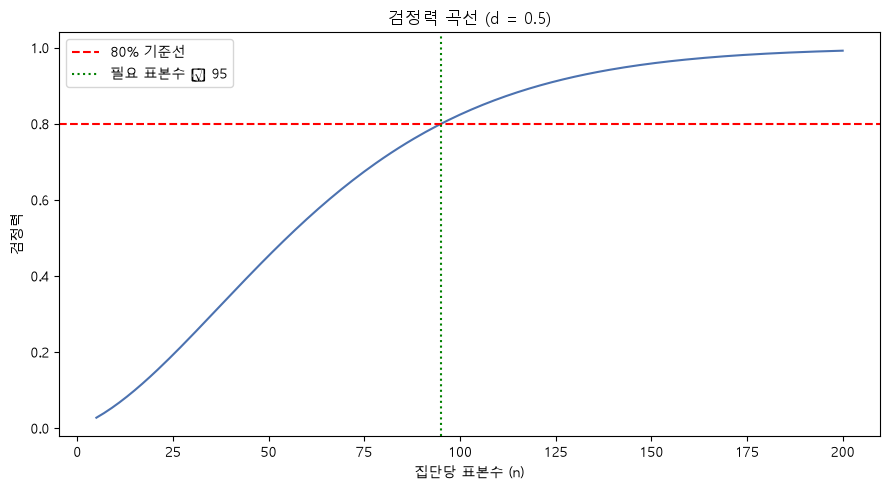

In [16]:
# Q4 · 검정력 곡선을 그려 봅시다
analysis = TTestIndPower()
n_range = np.arange(5, 201)
d = 0.5

powers = [analysis.power(effect_size=d, nobs1=n, alpha=0.01) for n in n_range]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_range, powers, color="#4C72B0")
ax.axhline(0.80, color="red", linestyle="--", label="80% 기준선")

# Q3에서 구한 필요 표본수(64) 표시
required_n = analysis.solve_power(effect_size=d, alpha=0.01, power=0.80)
ax.axvline(required_n, color="green", linestyle=":", label=f"필요 표본수 ≈ {required_n:.0f}")

ax.set_title("검정력 곡선 (d = 0.5)")
ax.set_xlabel("집단당 표본수 (n)")
ax.set_ylabel("검정력")
ax.legend()
plt.tight_layout()
plt.show()

💬 정리 · 결과를 말로 설명해 보기
Q3에서 펭귄의 32g 차이(d ≈ 0.074)를 80% 검정력으로 잡으려면 집단당 몇 마리가 필요했나요? 팔머 기지 데이터는 전체가 344마리입니다. 이 연구는 애초에 가능했을까요?
▸ d ≈ 0.074 기준 집단당 표본의 수는 2,868 마리가 필요했고 팔머 기지 데이터는 344마리로 애초에 불가능하였다.

검정력이 낮은 연구에서 "유의한 차이가 없었다"는 결과가 나왔을 때, 우리는 무엇을 알 수 있고 무엇을 알 수 없나요? (7장 문제 4 Q5의 Adelie 수컷 회귀를 떠올려 보세요)
▸ 7장 문제 4 Q5의 Adelie 수컷 회귀에서도 표본의 수가 줄어들어 p-값이 0.05 보다 높게 나타 귀무가설을 기각하지 못하였고 상관관계가 있다는 것을 입증하지 못했다.
이렇듯 검정력이 낮다면 효과가 있는데도 불구하고 귀무가설을 기각하지 못하여 제2종오류가 발생할 수 있게되고 충분한 표본이 아니라서 정확한 분석을 하지 못한다는 것을 알 수 있다.

실험을 시작하기 전에 표본수를 정해야 하는 이유는 무엇인가요? 데이터를 본 뒤에 정하면 무엇이 잘못될까요?
▸ 데이터를 본 뒤 표본 수를 조정하여 결과적으로 통계가 유의미한 결론으로 조작할 수 있는 p-해킹이 발생한다.

유의수준 alpha를 0.05에서 0.01로 낮추면 필요한 n은 늘어날까요, 줄어들까요? Q3의 코드를 고쳐 직접 계산해 확인해 보세요.
▸ 유의수준을 0.01로 낮춘다는 것은 유의수준이 95%가 아닌 99%로 더 보수적인 관점으로 평가하는 것을 의미하며, 충분한 분석에 도달하기 위해선 더 많은 n수를 필요로하게 됩니다.
펭귄 데이터를 기준으로 본다면 0.05 유의수준 기준 64개의 표본이 필요하지만 유의수준을 0.01로 줄이면 표본의 수도 95로 증가합니다.

"검출하고자 하는 효과크기를 얼마로 정할 것인가"는 통계 문제인가요, 도메인 문제인가요?
▸ 앞에서 분석한 32g의 차이가 실제 해당 분야에서 얼마만큼의 효과크기를 가지는지는 통계적인 계산값 보다는 도메인의 전문적인 지식을 토대로 보아야 한다.

In [17]:
# 문제 3 · 데이터 준비 — 실행만 하세요
N_SIM = 1000     # 시뮬레이션 반복 횟수
SEED  = 777      # 난수 시드 — Q1~Q4에서 각각 이 값으로 시작하면 몇 번 재실행해도 같은 결과가 나옵니다

print("이번 문제의 전제")
print("  두 집단 A, B는 모두 N(0, 1)에서 나옵니다 → 진짜 차이는 정확히 0")
print("  즉 귀무가설이 '참'인 상황이며, 유의하다는 결론은 모두 제1종 오류입니다.")
print("  절차를 지켰다면 오류율은 유의수준 5% 근처여야 합니다.")
print("\n각 조건마다 %d번씩 반복해 '유의하다고 결론 내린 비율'을 셉니다." % N_SIM)

이번 문제의 전제
  두 집단 A, B는 모두 N(0, 1)에서 나옵니다 → 진짜 차이는 정확히 0
  즉 귀무가설이 '참'인 상황이며, 유의하다는 결론은 모두 제1종 오류입니다.
  절차를 지켰다면 오류율은 유의수준 5% 근처여야 합니다.

각 조건마다 1000번씩 반복해 '유의하다고 결론 내린 비율'을 셉니다.


In [18]:
# Q1 · 정직한 분석의 제1종 오류율을 확인해 봅시다
N_SIM = 1000
SEED = 777

np.random.seed(SEED)

significant_count = 0

for i in range(N_SIM):
    group_a = np.random.normal(0, 1, 20)
    group_b = np.random.normal(0, 1, 20)
    
    t_stat, p_value = stats.ttest_ind(group_a, group_b)   # 딱 한 번만 검정
    
    if p_value < 0.05:
        significant_count += 1

type1_error_rate = significant_count / N_SIM

print(f"유의하다고 결론 내린 횟수: {significant_count} / {N_SIM}")
print(f"제1종 오류율: {type1_error_rate:.4f} ({type1_error_rate*100:.2f}%)")
print(f"이론적 기대값(유의수준): 0.05 (5%)")

유의하다고 결론 내린 횟수: 60 / 1000
제1종 오류율: 0.0600 (6.00%)
이론적 기대값(유의수준): 0.05 (5%)


In [19]:
# Q2 · 해킹 ① — 결과를 보고 표본을 더 모으면
N_SIM = 1000
SEED = 777

np.random.seed(SEED)

phacked_significant_count = 0

for i in range(N_SIM):
    n = 20
    found_significant = False
    
    for attempt in range(5):   # 최대 5번까지 반복
        group_a = np.random.normal(0, 1, n)
        group_b = np.random.normal(0, 1, n)
        
        t_stat, p_value = stats.ttest_ind(group_a, group_b)
        
        if p_value < 0.05:
            found_significant = True
            break   # "찾았다!" 하고 즉시 멈춤
        
        n += 10   # 각 집단에 10명씩 추가
    
    if found_significant:
        phacked_significant_count += 1

phacked_error_rate = phacked_significant_count / N_SIM

print(f"p-해킹으로 유의하다고 결론 내린 횟수: {phacked_significant_count} / {N_SIM}")
print(f"p-해킹 오류율: {phacked_error_rate:.4f} ({phacked_error_rate*100:.2f}%)")
print(f"\nQ1(정직한 검정) 오류율: 6.00%")
print(f"차이: {(phacked_error_rate*100 - 6.00):.2f}%p")


p-해킹으로 유의하다고 결론 내린 횟수: 211 / 1000
p-해킹 오류율: 0.2110 (21.10%)

Q1(정직한 검정) 오류율: 6.00%
차이: 15.10%p


In [20]:
#Q3 · 해킹 ② — 지표를 20개 재서 하나만 보고하면

N_SIM = 1000
SEED = 777
N_METRICS = 20

np.random.seed(SEED)

cherry_pick_count = 0

for i in range(N_SIM):
    found_significant = False
    
    for metric in range(N_METRICS):   # 20개 지표를 각각 검정
        group_a = np.random.normal(0, 1, 20)
        group_b = np.random.normal(0, 1, 20)
        
        t_stat, p_value = stats.ttest_ind(group_a, group_b)
        
        if p_value < 0.05:
            found_significant = True
            break   # 하나라도 유의하면 그것만 보고하고 멈춤
    
    if found_significant:
        cherry_pick_count += 1

cherry_pick_rate = cherry_pick_count / N_SIM
theoretical_rate = 1 - 0.95**20

print(f"20개 지표 중 하나라도 유의했던 비율: {cherry_pick_rate:.4f} ({cherry_pick_rate*100:.2f}%)")
print(f"이론값 (1 - 0.95^20): {theoretical_rate:.4f} ({theoretical_rate*100:.2f}%)")

20개 지표 중 하나라도 유의했던 비율: 0.6490 (64.90%)
이론값 (1 - 0.95^20): 0.6415 (64.15%)


Q1 (정직한 단일 검정): 6.00%
Q2 (p-해킹, 표본 늘리기): 21.10%
Q3 (체리피킹, 20개 지표): 64.90%
Q4 (Q3 + 본페로니 보정): 4.70%
보정 기준값(alpha): 0.0025


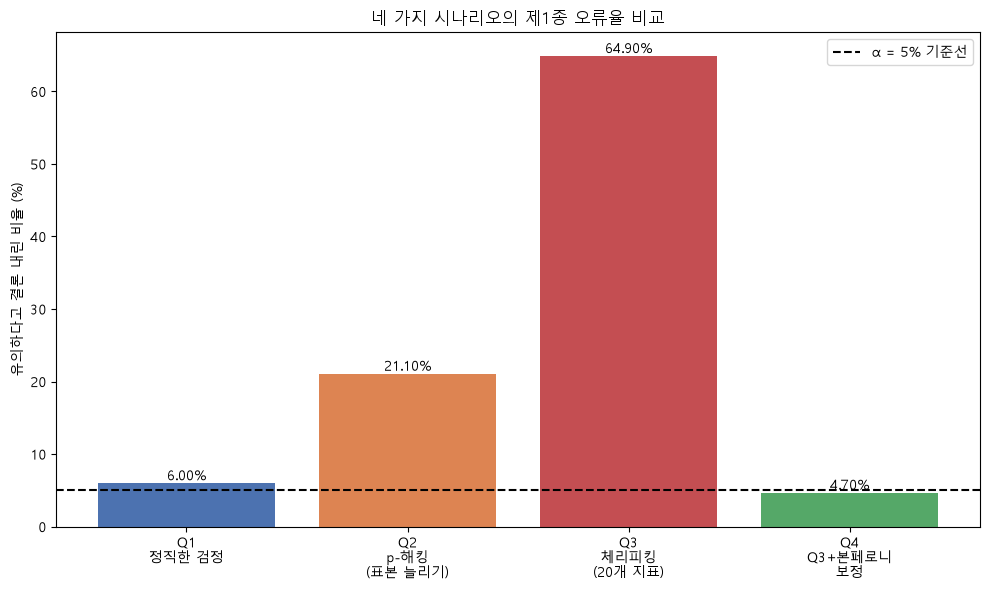

In [21]:
# Q4 · 세 결과를 나란히 놓고, 보정 효과까지 확인해 봅시다
N_SIM = 1000
SEED = 777
N_METRICS = 20

# ===== Q1: 정직한 단일 검정 =====
np.random.seed(SEED)
q1_count = 0
for i in range(N_SIM):
    a = np.random.normal(0, 1, 20)
    b = np.random.normal(0, 1, 20)
    _, p = stats.ttest_ind(a, b)
    if p < 0.05:
        q1_count += 1
q1_rate = q1_count / N_SIM

# ===== Q2: p-해킹 (표본 늘리기) =====
np.random.seed(SEED)
q2_count = 0
for i in range(N_SIM):
    n = 20
    found = False
    for attempt in range(5):
        a = np.random.normal(0, 1, n)
        b = np.random.normal(0, 1, n)
        _, p = stats.ttest_ind(a, b)
        if p < 0.05:
            found = True
            break
        n += 10
    if found:
        q2_count += 1
q2_rate = q2_count / N_SIM

# ===== Q3: 체리피킹 (20개 지표 중 하나) =====
np.random.seed(SEED)
q3_count = 0
for i in range(N_SIM):
    found = False
    for m in range(N_METRICS):
        a = np.random.normal(0, 1, 20)
        b = np.random.normal(0, 1, 20)
        _, p = stats.ttest_ind(a, b)
        if p < 0.05:
            found = True
            break
    if found:
        q3_count += 1
q3_rate = q3_count / N_SIM

# ===== Q4: Q3 + 본페로니 보정 =====
np.random.seed(SEED)
q4_count = 0
alpha_corrected = 0.05 / N_METRICS   # 0.0025
for i in range(N_SIM):
    found = False
    for m in range(N_METRICS):
        a = np.random.normal(0, 1, 20)
        b = np.random.normal(0, 1, 20)
        _, p = stats.ttest_ind(a, b)
        if p < alpha_corrected:
            found = True
            break
    if found:
        q4_count += 1
q4_rate = q4_count / N_SIM

# ===== 결과 출력 =====
print(f"Q1 (정직한 단일 검정): {q1_rate*100:.2f}%")
print(f"Q2 (p-해킹, 표본 늘리기): {q2_rate*100:.2f}%")
print(f"Q3 (체리피킹, 20개 지표): {q3_rate*100:.2f}%")
print(f"Q4 (Q3 + 본페로니 보정): {q4_rate*100:.2f}%")
print(f"보정 기준값(alpha): {alpha_corrected}")

# ===== 막대그래프 =====
labels = ["Q1\n정직한 검정", "Q2\np-해킹\n(표본 늘리기)", "Q3\n체리피킹\n(20개 지표)", "Q4\nQ3+본페로니\n보정"]
values = [q1_rate*100, q2_rate*100, q3_rate*100, q4_rate*100]
colors = ["#4C72B0", "#DD8452", "#C44E52", "#55A868"]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color=colors)
ax.bar_label(bars, fmt="%.2f%%")

ax.axhline(5, color="black", linestyle="--", linewidth=1.5, label="α = 5% 기준선")

ax.set_title("네 가지 시나리오의 제1종 오류율 비교")
ax.set_ylabel("유의하다고 결론 내린 비율 (%)")
ax.legend()
plt.tight_layout()
plt.show()


💬 정리 · 결과를 말로 설명해 보기
Q1의 값은 5%에 가까웠습니다. 이것이 뜻하는 바는 무엇인가요? 가설검정은 원래 무엇을 보장해 주는 도구인가요?
▸ 5% 즉 유의수준과 가까웠는데 귀무가설 기준 주장하고 있는 현상이 실제 데이터에서 발생할 확률임에 동시에 제 1종 오류를 범할 수 있는 확률에도 해당하며,
가설검정은 우리가 주장하고 있는 대립가설과 현 상태의 귀무가설을 기준으로 실제로 아무 차이가 없을 때(귀무가설이 참일 때), 우리가 잘못 판단할 확률(1종 오류)을 정확히 5%로 통제해주는 역할을 한다.

Q2와 Q3에서 오류율이 뛴 이유를 각각 설명해 보세요. 두 해킹의 메커니즘은 같나요, 다른가요?
▸ Q2의 경우 표본 20에서 시작하여 P값이 0.05 미만이 될때까지 10명씩 추가하여 다시 검정을 하였고
Q3의 경우 아무 차이 없는 지표 20개를 각각 20명씩 검정하여 P값이 0.05 미만인 경우만 출력한 것이다.
Q2는 결론에 도달하기 위해서 표본의 수를 조작하였고 Q3의 경우엔 유의미한 자료만 보고하는 해킹으로 매커니즘은 다르다.

Q3의 결과는 무엇을 뜻하나요? "지표 20개를 재고 유의한 하나만 보고한다"는 연구를 여러분은 신뢰할 수 있나요?
▸ 유의미한 결과만 보여준다면 실제 아무런 상관관계가 없는 지표들도 포함될 수 있기 때문에 연구는 신뢰할 수 없을 것 같습니다.

강의에 나온 HARKing(결과를 본 뒤에 가설을 만드는 행위)은 Q2·Q3 중 어느 쪽과 닮아 있나요?
▸ HARKing의 경우 Q3처럼 유의미한 결과만 보고하는 쪽과 닮아있습니다.

**사전 등록(Preregistration)**은 Q2와 Q3를 각각 어떻게 막아 주나요? 두 해킹에 대해 따로 설명해 보세요.
▸ 사전 등록의 경우에는 Q2, Q3 모두 막아줍니다.
처음부터 시험계획서에 n수를 정해놓기 때문에 Q2처럼 N수를 늘릴 수 없게 막아주고
보려고하는 1차 유효성 평가, 2차 유효성 평가에 사용될 변수와 분석 방법등이 기재되어 있기 때문에 다른 변수를 사용하거나 다른 분석방법으로 유의미한 결과를 제시할 수 없게된다.

문제 2에서 배운 '표본수 사전 설계'는 Q2를 막는 데 어떤 역할을 하나요?
▸ 분석 결과 유의미한 결과가 없는 경우 표본을 늘려 Q1(6.00%) -> Q2(21.10%)와 같이 일시적으로 유의미한 자료로 만들어 1종 오류가 발생할 수 있는데 표본수 사전 설계는 이러한 1종 오류를 줄이는 역할을 합니다.

In [22]:
# 문제 4 · 데이터 준비 (1/2) — 실행만 하세요
# 펭귄 부리 데이터: 7장 문제 1에서 봤던 그 데이터입니다.
bills = penguins.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'species'])

print("분석에 사용할 데이터: %d 행\n" % len(bills))
print("종별 부리 평균 —— '종'이 두 변수 모두에 영향을 주고 있다는 단서")
print(bills.groupby('species')[['bill_length_mm', 'bill_depth_mm']].mean().round(2))

분석에 사용할 데이터: 342 행

종별 부리 평균 —— '종'이 두 변수 모두에 영향을 주고 있다는 단서
           bill_length_mm  bill_depth_mm
species                                 
Adelie              38.79          18.35
Chinstrap           48.83          18.42
Gentoo              47.50          14.98


In [23]:
#Q1 · 전체 데이터로 부리 길이와 두께의 관계를 회귀로 확인해 봅시다
X = sm.add_constant(bills["bill_length_mm"])
y = bills["bill_depth_mm"]
model_pooled = sm.OLS(y, X).fit()

slope = model_pooled.params["bill_length_mm"]
p_value = model_pooled.pvalues["bill_length_mm"]

print(f"기울기: {slope:.4f}")
print(f"p-값: {p_value:.10f}")

기울기: -0.0850
p-값: 0.0000111966


In [ ]:
#Q2 · 종별로 층을 나눠 같은 회귀를 다시 해 봅시다
results = []

for species in bills["species"].unique():
    subset = bills[bills["species"] == species]
    
    X = sm.add_constant(subset["bill_length_mm"])
    y = subset["bill_depth_mm"]
    model_species = sm.OLS(y, X).fit()
    
    results.append({
        "종": species,
        "n": len(subset),
        "기울기": model_species.params["bill_length_mm"],
        "p-값": model_species.pvalues["bill_length_mm"]
    })

result_df = pd.DataFrame(results)
print(result_df.to_string(index=False))

        종   n      기울기          p-값
   Adelie 151 0.178834 6.674141e-07
Chinstrap  68 0.222212 1.525539e-09
   Gentoo 123 0.204844 1.015502e-15


In [ ]:
# Q3 · 종을 회귀식에 함께 넣어 통제해 봅시다
import statsmodels.formula.api as smf

model_controlled = smf.ols("bill_depth_mm ~ bill_length_mm + C(species)", data=bills).fit()

slope_controlled = model_controlled.params["bill_length_mm"]
p_value_controlled = model_controlled.pvalues["bill_length_mm"]
r_squared_controlled = model_controlled.rsquared

print("=== Q1 (종 통제 없음) vs Q3 (종 통제) 비교 ===")
print(f"{'구분':<20}{'기울기':>12}{'p-값':>15}{'R²':>10}")
print(f"{'Q1 (종 없음)':<20}{slope:>12.4f}{p_value:>15.2e}{model_pooled.rsquared:>10.4f}")
print(f"{'Q3 (종 통제)':<20}{slope_controlled:>12.4f}{p_value_controlled:>15.2e}{r_squared_controlled:>10.4f}")

=== Q1 (종 통제 없음) vs Q3 (종 통제) 비교 ===
구분                           기울기            p-값        R²
Q1 (종 없음)                -0.0850       1.12e-05    0.0552
Q3 (종 통제)                 0.1999       8.66e-26    0.7690


In [29]:
# 문제 4 · 데이터 준비 (2/2) — 실행만 하세요
# 같은 학생 2,000명에게 '새 온라인 강의'를 배정하는 두 가지 방식
TRUE_EFFECT = 5.0                      # 강의의 진짜 효과: 기말고사 +5점
rng = np.random.default_rng(279)
n = 2000

pre_score   = rng.normal(60, 10, n)    # 교란요인 ① 사전 성적
study_hours = rng.normal(10,  3, n)    # 교란요인 ② 주당 학습시간

# 잠재결과 — 두 교란요인은 결과(기말고사 성적)에도 직접 영향을 줍니다
Y0 = 20 + 0.7 * pre_score + 0.8 * study_hours + rng.normal(0, 5, n)  # 강의를 안 들었을 때
Y1 = Y0 + TRUE_EFFECT                                                 # 강의를 들었을 때

# (A) 관찰연구 — 성적 좋고 열심인 학생이 스스로 신청 (선택 편향)
signup_logit = -0.6 + 0.10 * (pre_score - 60) + 0.20 * (study_hours - 10)
course_obs = rng.binomial(1, 1 / (1 + np.exp(-signup_logit)))

# (B) 무작위 통제 실험 — 동전을 던져 배정
course_rct = rng.binomial(1, 0.5, n)

df_obs = pd.DataFrame({'pre_score': pre_score, 'study_hours': study_hours,
                       'course': course_obs, 'final_score': np.where(course_obs == 1, Y1, Y0)})
df_rct = pd.DataFrame({'pre_score': pre_score, 'study_hours': study_hours,
                       'course': course_rct, 'final_score': np.where(course_rct == 1, Y1, Y0)})

print("참 효과(우리가 추정해야 하는 값): %.1f점\n" % TRUE_EFFECT)
print("관찰연구 df_obs — 수강생 %d명 (%.1f%%)" % (df_obs['course'].sum(), df_obs['course'].mean()*100))
print("RCT      df_rct — 수강생 %d명 (%.1f%%)" % (df_rct['course'].sum(), df_rct['course'].mean()*100))

참 효과(우리가 추정해야 하는 값): 5.0점

관찰연구 df_obs — 수강생 751명 (37.5%)
RCT      df_rct — 수강생 1012명 (50.6%)


In [ ]:
# Q5 · 같은 학생들을 동전 던지기로 배정하면 어떻게 될까요
# 1. 단순 평균 차이 (RCT)
naive_diff_rct = df_rct.loc[df_rct["course"]==1, "final_score"].mean() - \
                 df_rct.loc[df_rct["course"]==0, "final_score"].mean()

# 2. 회귀보정 차이 (RCT) - 교란요인을 통제
model_rct = smf.ols("final_score ~ course + pre_score + study_hours", data=df_rct).fit()
adjusted_diff_rct = model_rct.params["course"]

print(f"참 효과: 5.0점\n")
print(f"[RCT] 단순 평균 차이: {naive_diff_rct:.3f}점")
print(f"[RCT] 회귀보정 차이: {adjusted_diff_rct:.3f}점")

# 3. 교란요인 균형표
balance_table = pd.DataFrame({
    "관찰연구(df_obs) 차이": [
        df_obs.loc[df_obs["course"]==1, "pre_score"].mean() - df_obs.loc[df_obs["course"]==0, "pre_score"].mean(),
        df_obs.loc[df_obs["course"]==1, "study_hours"].mean() - df_obs.loc[df_obs["course"]==0, "study_hours"].mean()
    ],
    "RCT(df_rct) 차이": [
        df_rct.loc[df_rct["course"]==1, "pre_score"].mean() - df_rct.loc[df_rct["course"]==0, "pre_score"].mean(),
        df_rct.loc[df_rct["course"]==1, "study_hours"].mean() - df_rct.loc[df_rct["course"]==0, "study_hours"].mean()
    ]
}, index=["pre_score", "study_hours"])

print("\n=== 교란요인 균형표 (수강 vs 미수강 그룹 간 차이) ===")
print(balance_table.round(3))

참 효과: 5.0점

[RCT] 단순 평균 차이: 4.981점
[RCT] 회귀보정 차이: 4.937점

=== 교란요인 균형표 (수강 vs 미수강 그룹 간 차이) ===
             관찰연구(df_obs) 차이  RCT(df_rct) 차이
pre_score              7.687           0.071
study_hours            1.382          -0.008


💬 정리 · 결과를 말로 설명해 보기
Q1의 기울기는 음수인데 Q2·Q3의 기울기는 양수였습니다. 같은 데이터에서 부호가 뒤집힌 이유는 무엇인가요? 이 현상의 이름은 무엇인가요?
▸ Q1 펭귄 전체의 기울기는 음수(-0.0850)였고 Q2,Q3 종별 층화에 따른 기울기는 Adelie 0.0178, Chinstrap 0.2222, Gentoo 0.2048로 모두 양수였습니다.
이는 산점도와 상관분석에서 전체의 지표가 잘못된 착시를 보여주는 심슨의 역설입니다.

Q2(층별 분석)와 Q3(다중회귀)는 같은 결론을 줬습니다. 두 방법의 차이는 무엇인가요? 층이 아주 많아지면 어느 쪽이 유리할까요?
▸ 층별 분석은 어떠한 층화 요인을 추가하여 분석을 하는 것이고 다중회귀는 여러 변수를 회귀하여 분석하는 것이다.
층이 아주 많아진다면 각 층별로 표본의 수가 너무 감소하게 때문에 다중회귀 분석하는 것이 좀 더 유의미한 결과를 찾을 수 있어서 유리하다.

Q4에서 관찰연구의 단순 비교값은 참 효과 5점과 크게 달랐습니다. 교란요인 균형 표를 근거로 그 이유를 설명해 보세요.
▸ 관찰연구에서는 pre_score(7.687)와 study_hours(1.382)의 차이를 보이며 해당 두 요인을 모두 통제하지 않아 관찰연구의 단순 비교값이 참 효과 5점과 크게 다르게 나타나였습니다.

Q5의 RCT는 pre_score도 study_hours도 통제하지 않았는데 참값에 가까웠습니다. 어떻게 이런 일이 가능한가요?
▸ RCT의 경우 무작위배정으로 A, B 그룹간의 교란요인의 분포가 서로 비슷하게 배정한다. 그렇기 때문에 RCT: pre_score 차이 0.071, study_hours 차이 -0.008와 같이 0에 근접한 차이를 보이지만 별도로 통제하지 않은 관찰연구에서는 pre_score 차이 7.687, study_hours 차이 1.382의 차이를 보이고 RCT에선 별도의 통제가 없어도 참값(5.0점)에 가까운 결과가 나올 수 있었던 것이다.


통제(Q3)와 무작위화(Q5)의 결정적 차이는 무엇인가요? 우리가 아직 모르는 교란요인이 있다면 어느 쪽이 안전한가요?
▸ 통제(Q3)의 경우엔 우리가 처음부터 인지하고 있는 교란요인을 알고 있어 그 요인들을 통제할 수 있으나 무작위화(Q5)의 경우엔 교란요인과 상관없이 A, B 그룹에 무작위로 대상자를 배정하고 그 그룹간의 차이가 애초에 크게 발생하지 않도록 하기 때문에 우리가 모르는 교란요인이 많다면 무작위화가 더 안전하다.

그런데 현실에서 RCT가 늘 가능한가요? 불가능한 예를 두 개 들어 보세요.
▸ 임상시험 신약 개발에서는 RCT를 하는 경우 잘못된 치료를 받을 수 있는 윤리적인 문제가 있을 수 있으며, 무작위배정으로 인하여 두개의 군간에 적절한 표본을 모으기도 시간적, 비용적인 측면에서도 어려움이 있을 수 있습니다.

In [31]:
# 문제 5 · 데이터 준비 (1/2) — 실행만 하세요
# 문제 4에서 만든 관찰연구 데이터(df_obs)를 그대로 이어서 씁니다.
print("관찰연구 데이터 df_obs: %d행" % len(df_obs))
print("  수강생 %d명 / 비수강생 %d명" % ((df_obs['course']==1).sum(), (df_obs['course']==0).sum()))
print("  단순 평균 비교(문제 4 Q4): %+.2f점" % (
    df_obs.loc[df_obs['course']==1, 'final_score'].mean()
    - df_obs.loc[df_obs['course']==0, 'final_score'].mean()))
print("  우리가 되찾아야 하는 참 효과: %+.1f점" % TRUE_EFFECT)

관찰연구 데이터 df_obs: 2000행
  수강생 751명 / 비수강생 1249명
  단순 평균 비교(문제 4 Q4): +11.34점
  우리가 되찾아야 하는 참 효과: +5.0점


Optimization terminated successfully.
         Current function value: 0.553719
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 course   No. Observations:                 2000
Model:                          Logit   Df Residuals:                     1997
Method:                           MLE   Df Model:                            2
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.1633
Time:                        15:14:57   Log-Likelihood:                -1107.4
converged:                       True   LL-Null:                       -1323.6
Covariance Type:            nonrobust   LLR p-value:                 1.277e-94
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -8.6603      0.469    -18.474      0.000      -9.579      -7.742
pre_score       0.1008    

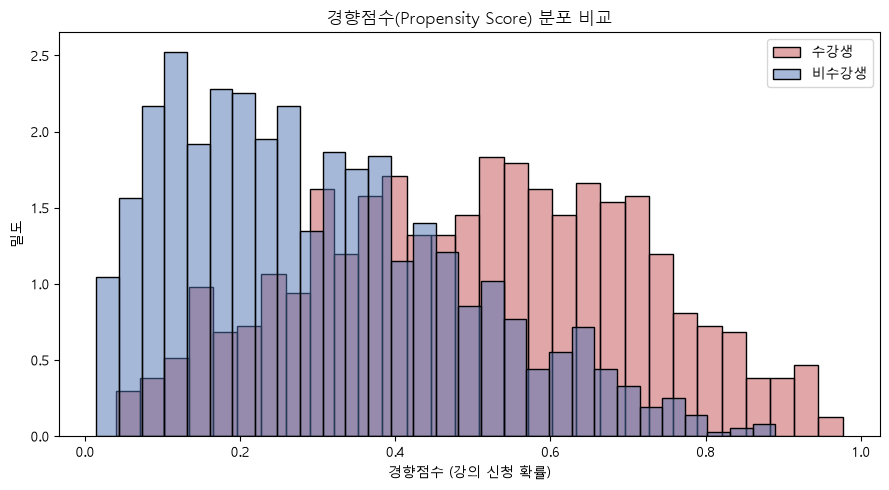

In [32]:
#Q1 · 경향점수를 추정해 봅시다
# 1. 로지스틱 회귀로 경향점수 추정
ps_model = smf.logit("course ~ pre_score + study_hours", data=df_obs).fit()
df_obs["ps"] = ps_model.predict(df_obs)

print(ps_model.summary())

# 2. 수강생 vs 비수강생의 경향점수 분포 겹쳐 그리기
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df_obs.loc[df_obs["course"]==1, "ps"], bins=30, color="#C44E52", 
             label="수강생", alpha=0.5, stat="density", ax=ax)
sns.histplot(df_obs.loc[df_obs["course"]==0, "ps"], bins=30, color="#4C72B0", 
             label="비수강생", alpha=0.5, stat="density", ax=ax)

ax.set_title("경향점수(Propensity Score) 분포 비교")
ax.set_xlabel("경향점수 (강의 신청 확률)")
ax.set_ylabel("밀도")
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
#Q2 · 1:1 짝짓기로 ATT를 추정해 봅시다
from sklearn.neighbors import NearestNeighbors

treated = df_obs[df_obs["course"] == 1].reset_index(drop=True)
control = df_obs[df_obs["course"] == 0].reset_index(drop=True)

# 대조군의 경향점수로 최근접이웃 모델 학습
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["ps"]])

# 각 수강생마다, 가장 가까운 비수강생 1명을 찾음
distances, indices = nn.kneighbors(treated[["ps"]])

matched_control = control.iloc[indices.flatten()].reset_index(drop=True)

# ATT 계산: 짝지어진 두 집단의 final_score 평균 차이
att = treated["final_score"].mean() - matched_control["final_score"].mean()

naive_diff = df_obs.loc[df_obs["course"]==1, "final_score"].mean() - \
             df_obs.loc[df_obs["course"]==0, "final_score"].mean()

print(f"① 단순 평균 비교(문제 4): {naive_diff:+.3f}점")
print(f"② PSM 이후 ATT:          {att:+.3f}점")
print(f"③ 참 효과:                {TRUE_EFFECT:+.1f}점")


① 단순 평균 비교(문제 4): +11.337점
② PSM 이후 ATT:          +5.017점
③ 참 효과:                +5.0점


In [35]:
# 짝짓기 전 차이 (전체 df_obs 기준)
before_pre_score = df_obs.loc[df_obs["course"]==1, "pre_score"].mean() - \
                    df_obs.loc[df_obs["course"]==0, "pre_score"].mean()
before_study_hours = df_obs.loc[df_obs["course"]==1, "study_hours"].mean() - \
                      df_obs.loc[df_obs["course"]==0, "study_hours"].mean()

# 짝짓기 후 차이 (treated vs matched_control 기준)
after_pre_score = treated["pre_score"].mean() - matched_control["pre_score"].mean()
after_study_hours = treated["study_hours"].mean() - matched_control["study_hours"].mean()

balance_check = pd.DataFrame({
    "짝짓기 전 차이": [before_pre_score, before_study_hours],
    "짝짓기 후 차이": [after_pre_score, after_study_hours]
}, index=["pre_score", "study_hours"])

print(balance_check.round(3))

             짝짓기 전 차이  짝짓기 후 차이
pre_score       7.687     0.074
study_hours     1.382     0.025


In [36]:
# 문제 5 · 데이터 준비 (2/2) — 실행만 하세요
# 서울(실험군) / 부산(통제군)의 1인당 월 데이터 사용량(GB), 2020~2025년
POLICY_YEAR = 2024        # 서울시가 무료 공공 와이파이를 도입한 해
TRUE_DID    = 4.0         # 정책의 진짜 효과: +4 GB
rng = np.random.default_rng(2024)

records = []
for city, baseline, is_seoul in [('서울', 15.0, 1), ('부산', 10.0, 0)]:
    for person in range(300):
        person_effect = rng.normal(0, 2.0)                  # 사람마다 타고난 사용량 차이
        for year in range(2020, 2026):
            time_trend = 1.5 * (year - 2020)                # 두 도시에 똑같이 작용하는 시간 추세
            policy = TRUE_DID if (is_seoul and year >= POLICY_YEAR) else 0.0
            records.append((city, is_seoul, person + is_seoul * 300, year,
                            baseline + person_effect + time_trend + policy + rng.normal(0, 1.0)))

panel = pd.DataFrame(records, columns=['city', 'is_seoul', 'person_id', 'year', 'data_usage'])

print("패널 데이터: %d행 (도시 2 × 300명 × 6년)" % len(panel))
print("정책 시행: %d년, 서울만  /  참 효과: +%.1f GB\n" % (POLICY_YEAR, TRUE_DID))
print(panel.groupby(['year', 'city'])['data_usage'].mean().unstack().round(2))

패널 데이터: 3600행 (도시 2 × 300명 × 6년)
정책 시행: 2024년, 서울만  /  참 효과: +4.0 GB

city     부산     서울
year              
2020  10.16  14.69
2021  11.54  16.27
2022  13.08  17.71
2023  14.60  19.22
2024  16.11  24.74
2025  17.59  26.36


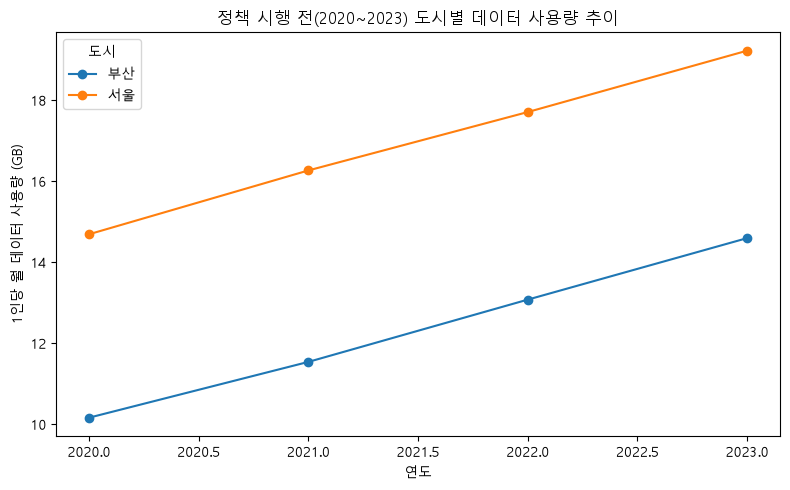

city      부산      서울  격차(서울-부산)
year                           
2020  10.162  14.690      4.528
2021  11.539  16.266      4.727
2022  13.077  17.707      4.631
2023  14.595  19.223      4.628


In [37]:
# 정책 시행 이전(2020~2023)만 필터링
pre_policy = panel[panel["year"] < POLICY_YEAR]
yearly_avg = pre_policy.groupby(["year", "city"])["data_usage"].mean().unstack()

# 꺾은선 그래프
fig, ax = plt.subplots(figsize=(8, 5))
yearly_avg.plot(marker="o", ax=ax)
ax.set_title("정책 시행 전(2020~2023) 도시별 데이터 사용량 추이")
ax.set_xlabel("연도")
ax.set_ylabel("1인당 월 데이터 사용량 (GB)")
ax.legend(title="도시")
plt.tight_layout()
plt.show()

# 연도별 격차(서울 - 부산) 출력
yearly_avg["격차(서울-부산)"] = yearly_avg["서울"] - yearly_avg["부산"]
print(yearly_avg.round(3))

In [ ]:
#Q5 · 2×2 DiD 회귀로 정책효과를 추정해 봅시다
# 2023, 2024년만 필터링
did_data = panel[panel["year"].isin([2023, 2024])].copy()
did_data["is_post"] = (did_data["year"] == 2024).astype(int)

# DiD 회귀: is_seoul + is_post + 상호작용항
model_did = smf.ols("data_usage ~ is_seoul + is_post + is_seoul:is_post", data=did_data).fit()

print(model_did.summary())

print(f"\n상호작용항(is_seoul:is_post) 계수: {model_did.params['is_seoul:is_post']:.4f}")
print(f"참 효과: {TRUE_DID:.1f}")

                            OLS Regression Results                            
Dep. Variable:             data_usage   R-squared:                       0.755
Model:                            OLS   Adj. R-squared:                  0.755
Method:                 Least Squares   F-statistic:                     1230.
Date:                Thu, 30 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:20:39   Log-Likelihood:                -2655.2
No. Observations:                1200   AIC:                             5318.
Df Residuals:                    1196   BIC:                             5339.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           14.5950      0.128  

① 경향점수 매칭(PSM) 분석 — 온라인 강의 효과

관찰연구 데이터에서 단순 평균 비교는 수강생과 비수강생의 사전 특성(사전성적·학습시간) 차이로 인해 강의 효과를 +11.3점으로 심각하게 과대추정하였으나, 사전성적과 학습시간을 이용한 경향점수를 추정하고 1:1 최근접 매칭을 실시한 결과 두 공변량의 그룹 간 차이가 매칭 후 각각 0.07점·0.03시간 수준으로 크게 감소하여(균형 확인) 매칭된 표본에서 추정한 ATT는 +5.0점으로 나타났으며, 이는 별도로 확보한 무작위 실험(RCT) 결과(+5.0점)와도 부합하는 값이다.

② 이중차분법(DiD) 분석 — 공공 와이파이 정책 효과

서울의 공공 와이파이 정책 효과를 부산을 통제집단으로 삼아 이중차분법으로 추정한 결과, 정책 시행 이전(2020~2023년) 두 도시의 데이터 사용량 격차가 안정적으로 유지되어 평행추세 가정이 뒷받침되었으며, 정책 직전·직후 연도(2023·2024년)만을 이용한 2×2 DiD 회귀에서 상호작용항 계수(+4.01GB, p<0.001)가 순수한 정책효과를 나타내어 사전에 설계된 참 효과(+4.0GB)와 거의 정확히 일치하였다.

💬 정리 · 결과를 말로 설명해 보기
Q2의 ATT는 참값 5점에 가까웠고, 문제 4의 단순 비교는 크게 벗어났습니다. PSM이 한 일을 한 문장으로 설명해 보세요.
▸

Q3의 균형 표에서 짝짓기 후 교란요인 차이는 어떻게 변했나요? 만약 짝짓기 후에도 차이가 크게 남아 있었다면 어떻게 해야 할까요?
▸

PSM은 경향점수 모형에 넣은 변수만 균형을 맞춥니다. 만약 관측하지 못한 교란요인 (예: 학생의 타고난 이해력)이 있다면, Q2의 ATT를 인과효과라고 부를 수 있을까요? 문제 4의 RCT와 비교해서 답해 보세요.
▸

Q4에서 정책 이전 4년간 두 도시의 격차는 거의 일정했습니다. 이것이 DiD의 어떤 가정을 지지하나요? 만약 이전부터 격차가 벌어지고 있었다면 Q5의 계수를 어떻게 읽어야 할까요?
▸

Q5의 상호작용항이 왜 정책효과인가요? 네 개 평균값을 직접 계산해 (A₂ − A₁) − (B₂ − B₁)과 일치하는지 확인해 보세요.
▸

Q6의 플라시보 검정이 만약 유의하게 나왔다면, 우리는 무엇을 의심해야 하나요?
▸

PSM과 DiD는 각각 어떤 상황에 쓰는 도구인가요? 두 방법의 데이터 요구조건 (단면 데이터 vs 패널 데이터)은 어떻게 다른가요?
▸